In [1]:
from jax import random, numpy as jnp
from lqg import xcorr
import matplotlib.pyplot as plt

from cppp.models.multisensory import MultisensoryDelayModel, MultisensoryDelayModelPointMassDynamics


In [15]:
force_model = MultisensoryDelayModelPointMassDynamics(
        process_noise=1.0,
        sigmas=[1.0],
        action_variability=0.5,
        action_cost=0.1,
        m=0.1,
        tau=0.066,
        dt=0.075,
        delays=[1],
        T=1000,
)

vel_model = MultisensoryDelayModel(
        process_noise=1.0,
        sigmas=[1.0],
        action_variability=0.5,
        action_cost=0.1,
        dt=0.075,
        delays=[1],
        T=1000,
)



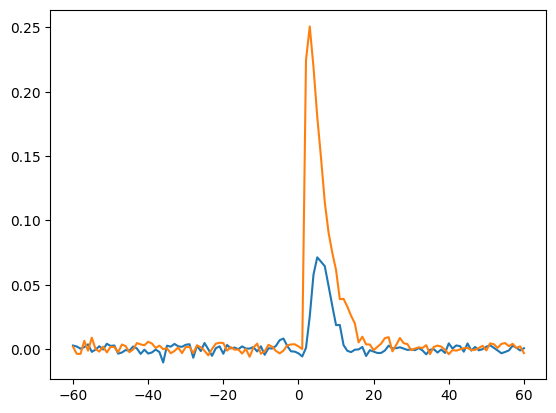

In [16]:
for model in [force_model, vel_model]:
    key = random.PRNGKey(0)
    x = model.simulate(key, n=100)
    print(model)
    vels = jnp.diff(x, axis=-2)
    lags, correls = xcorr(vels[..., 1], vels[..., 0], maxlags=60)

    plt.plot(lags, correls.mean(axis=0))